# Proyecto: Predicción de diabetes

## Árbol de Decisión

El objetivo es construir un modelo de clasificación que permita predecir si un paciente tiene diabetes (`Outcome = 1`) o no (`Outcome = 0`) a partir de distintas medidas diagnósticas.

# Paso 1: Carga del conjunto de datos

In [3]:
import os
import warnings
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme()

In [4]:

df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")
df.to_csv("../data/raw/diabetes.csv")

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Paso 2: Análisis Exploratorio de Datos (EDA)

## 2.1 Exploración inicial

In [5]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
display(df.head())
display(df.dtypes)
df.info()

Filas: 768
Columnas: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2.2 Valores faltantes

In [7]:
missing = pd.DataFrame({
    "cantidad": df.isnull().sum(),
    "porcentaje": (df.isnull().mean() * 100).round(2)
})
missing

,cantidad,porcentaje
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


## 2.3 Registros duplicados

In [8]:
duplicados = df.duplicated().sum()
print("Duplicados:", duplicados)
print("Porcentaje:", round((duplicados / len(df)) * 100, 2), "%")

Duplicados: 0
Porcentaje: 0.0 %


In [9]:
df[df.duplicated(keep=False)].head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [10]:
df = df.drop_duplicates().copy()
print("Dimensiones después de eliminar duplicados:", df.shape)

Dimensiones después de eliminar duplicados: (768, 9)


## 2.4 Revisión de valores cero

In [11]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_summary = pd.DataFrame({
    "cantidad_ceros": [(df[col] == 0).sum() for col in zero_columns],
    "porcentaje_ceros": [round((df[col] == 0).mean() * 100, 2) for col in zero_columns]
}, index=zero_columns)
zero_summary

,cantidad_ceros,porcentaje_ceros
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


## 2.5 Tratamiento de valores cero

In [12]:
for columna in zero_columns:
    df[columna] = df[columna].replace(0, df[columna].median())

df[zero_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Glucose,768.0,121.656250,30.438286,44.0,99.75,117.00,140.25,199.0
BloodPressure,768.0,72.386719,12.096642,24.0,64.00,72.00,80.00,122.0
SkinThickness,768.0,27.334635,9.229014,7.0,23.00,23.00,32.00,99.0
Insulin,768.0,94.652344,105.547598,14.0,30.50,31.25,127.25,846.0
BMI,768.0,32.450911,6.875366,18.2,27.50,32.00,36.60,67.1


## 2.6 Variable objetivo

In [13]:
print(df["Outcome"].value_counts())
print("\nPorcentajes:")
print((df["Outcome"].value_counts(normalize=True) * 100).round(2))

Outcome
0    500
1    268
Name: count, dtype: int64

Porcentajes:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


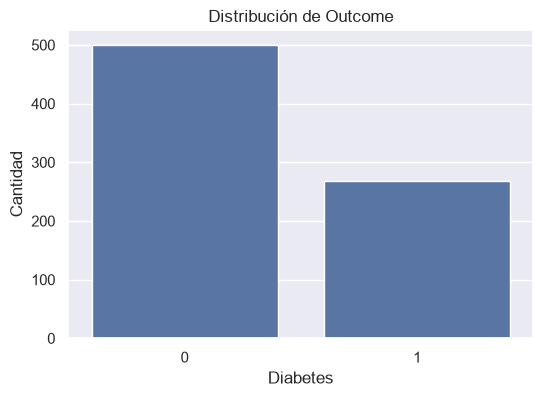

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Outcome")
plt.title("Distribución de Outcome")
plt.xlabel("Diabetes")
plt.ylabel("Cantidad")
plt.show()

## 2.7 Análisis univariante

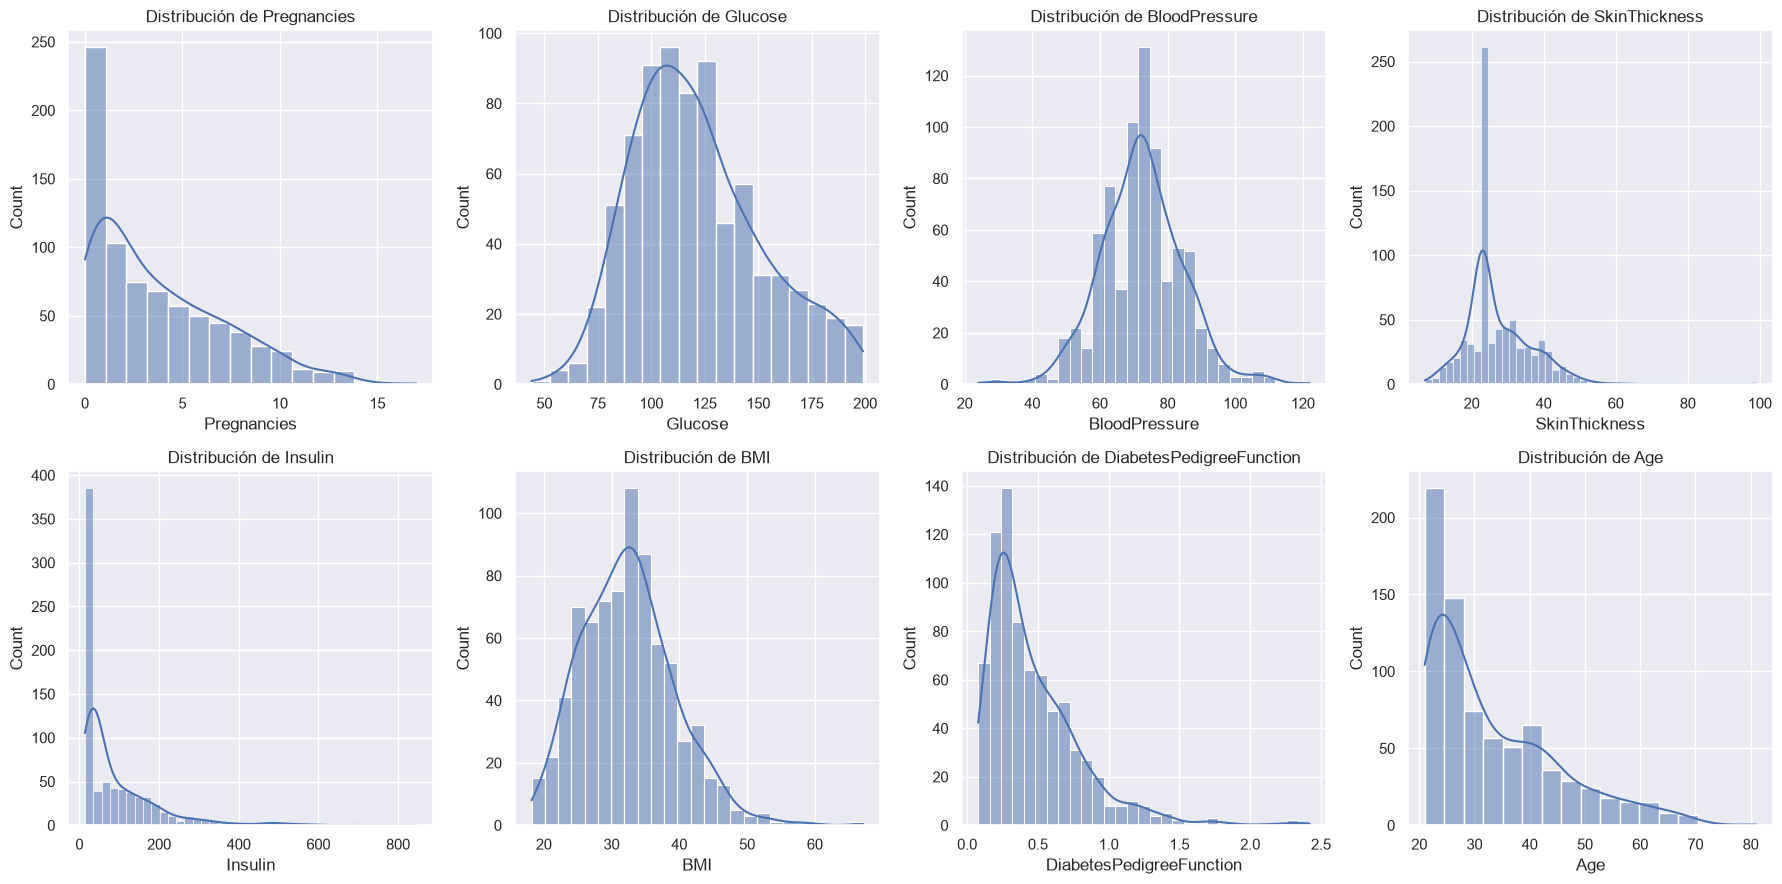

In [15]:
numerical_columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, columna in zip(axes.flatten(), numerical_columns):
    sns.histplot(data=df, x=columna, kde=True, ax=ax)
    ax.set_title(f"Distribución de {columna}")
plt.tight_layout()
plt.show()

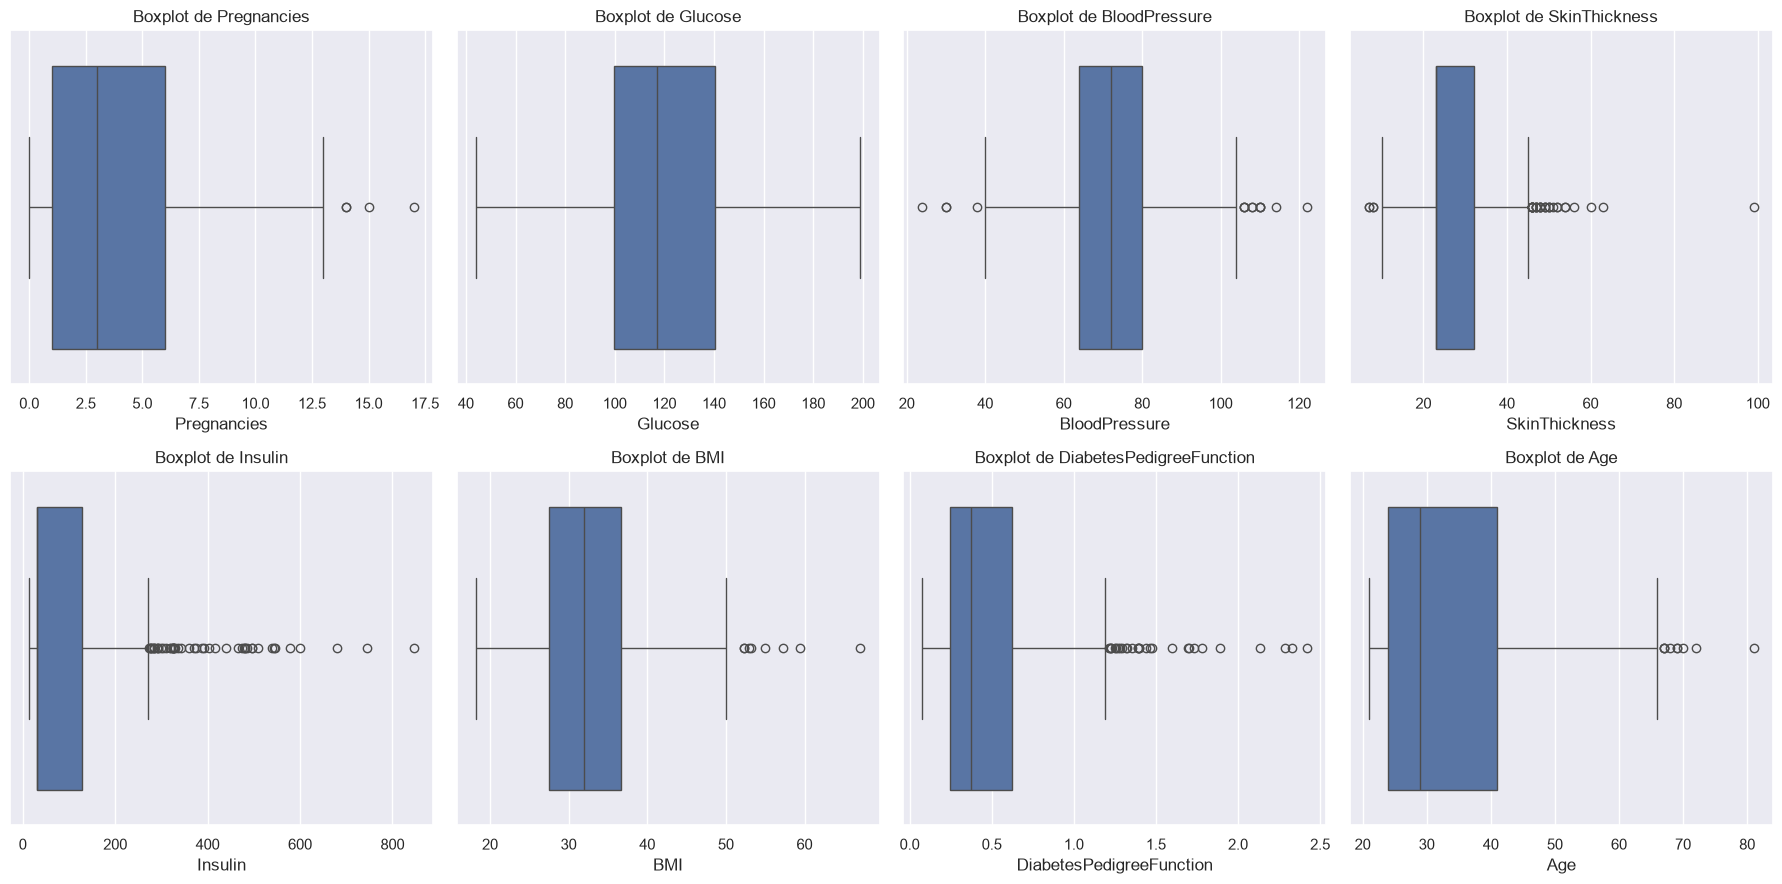

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, columna in zip(axes.flatten(), numerical_columns):
    sns.boxplot(data=df, x=columna, ax=ax)
    ax.set_title(f"Boxplot de {columna}")
plt.tight_layout()
plt.show()

## 2.8 Correlación entre variables

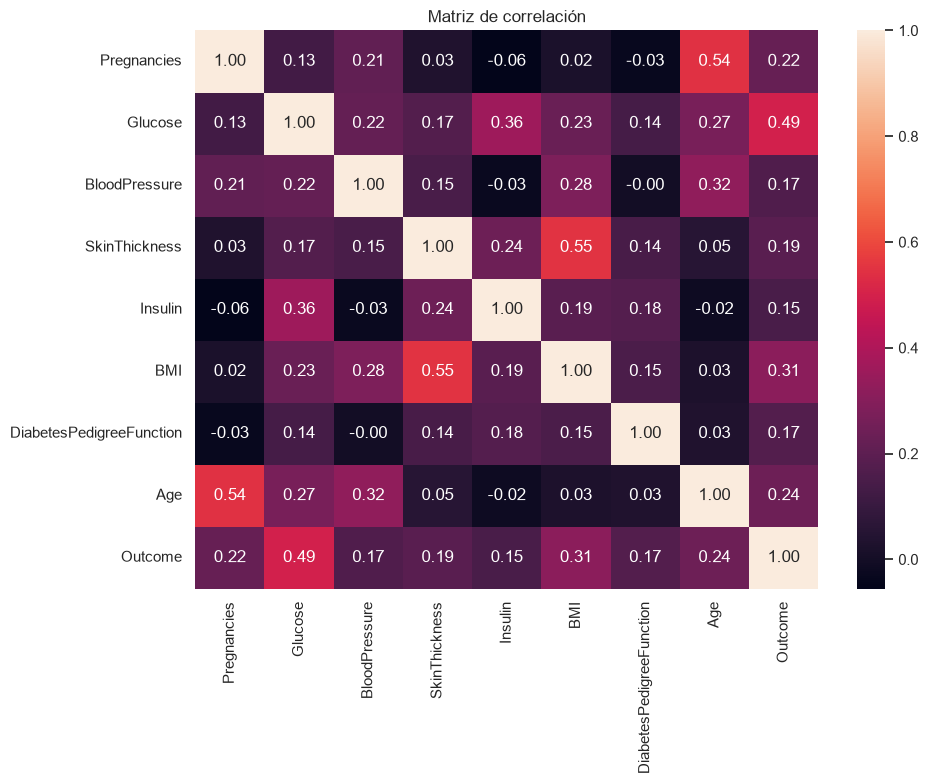

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

## 2.9 Relación de variables con Outcome

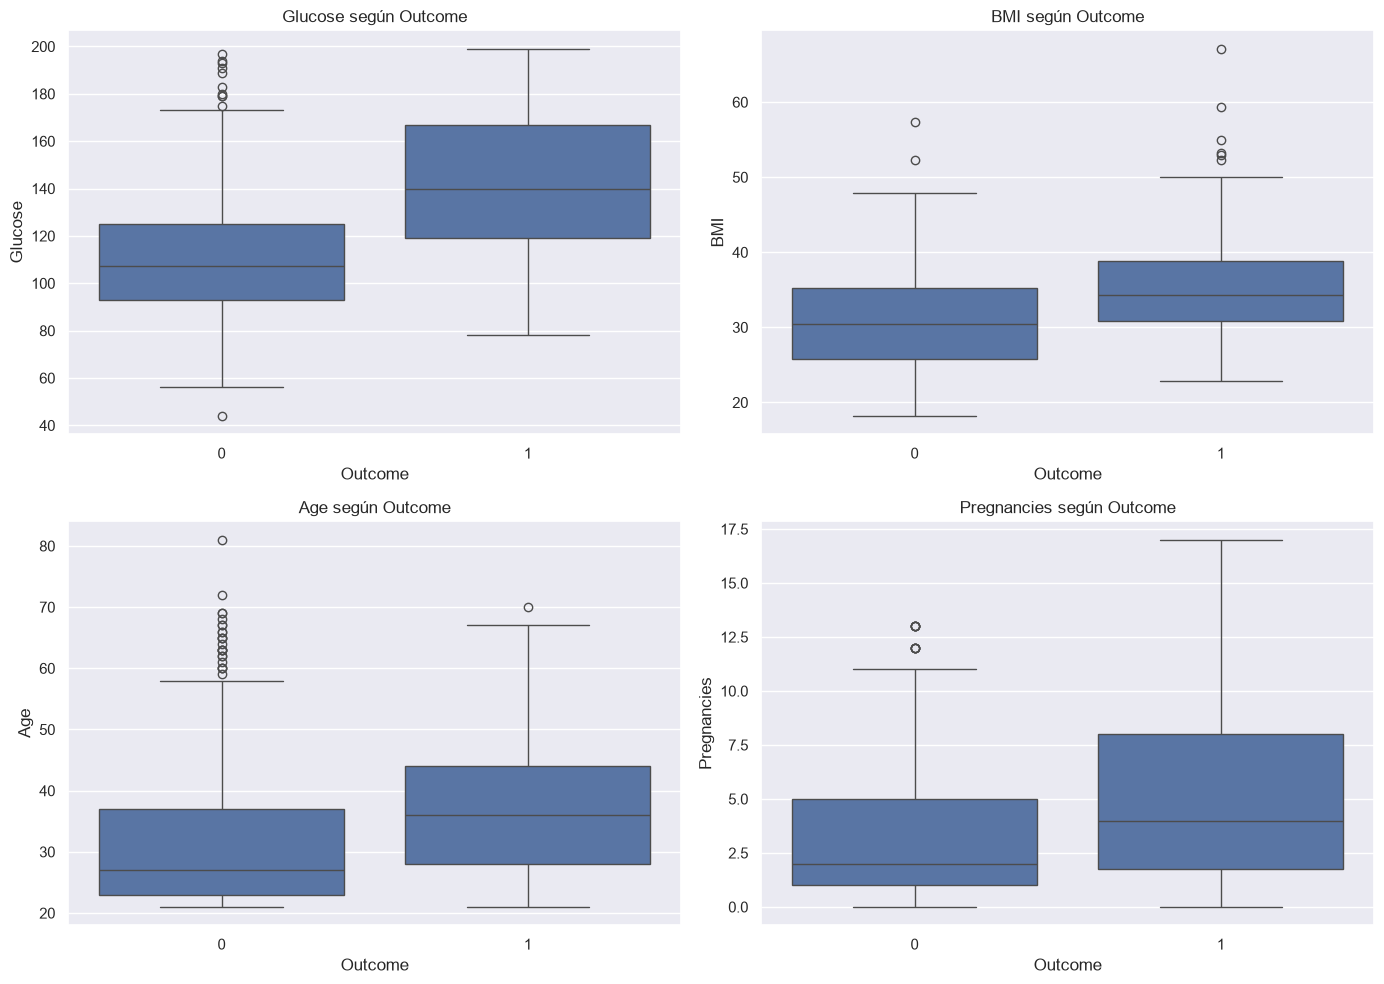

In [18]:
variables_target = ["Glucose", "BMI", "Age", "Pregnancies"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, columna in zip(axes.flatten(), variables_target):
    sns.boxplot(data=df, x="Outcome", y=columna, ax=ax)
    ax.set_title(f"{columna} según Outcome")
plt.tight_layout()
plt.show()

## 2.10 División en train y test

In [19]:
X = df.drop(columns="Outcome")
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

# Guardar conjuntos de entrenamiento y prueba
X_train.to_csv(processed_path / "X_train.csv", index=False)
X_test.to_csv(processed_path / "X_test.csv", index=False)

y_train.to_csv(processed_path / "y_train.csv", index=False)
y_test.to_csv(processed_path / "y_test.csv", index=False)

Train: (614, 8)
Test: (154, 8)


# Paso 3: Construcción del Árbol de Decisión

## 3.1 Modelo inicial con criterio Gini

In [20]:
tree_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
tree_gini.fit(X_train, y_train)
y_pred_gini = tree_gini.predict(X_test)
y_prob_gini = tree_gini.predict_proba(X_test)[:, 1]

In [21]:
metrics_gini = pd.Series({
    "accuracy": accuracy_score(y_test, y_pred_gini),
    "precision": precision_score(y_test, y_pred_gini, zero_division=0),
    "recall": recall_score(y_test, y_pred_gini, zero_division=0),
    "f1": f1_score(y_test, y_pred_gini, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_gini)
})
metrics_gini

accuracy     0.668831
precision    0.533333
recall       0.444444
f1           0.484848
roc_auc      0.617222
dtype: float64

## 3.2 Comparación de criterios de pureza

In [22]:
criterios = ["gini", "entropy", "log_loss"]
resultados = []
modelos_criterio = {}

for criterio in criterios:
    modelo = DecisionTreeClassifier(criterion=criterio, random_state=42)
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    prob = modelo.predict_proba(X_test)[:, 1]
    modelos_criterio[criterio] = modelo
    resultados.append({
        "criterion": criterio,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob)
    })

comparison_criteria = pd.DataFrame(resultados)
comparison_criteria

,criterion,accuracy,precision,recall,f1,roc_auc
0,gini,0.668831,0.533333,0.444444,0.484848,0.617222
1,entropy,0.662338,0.517857,0.537037,0.527273,0.633519
2,log_loss,0.662338,0.517857,0.537037,0.527273,0.633519


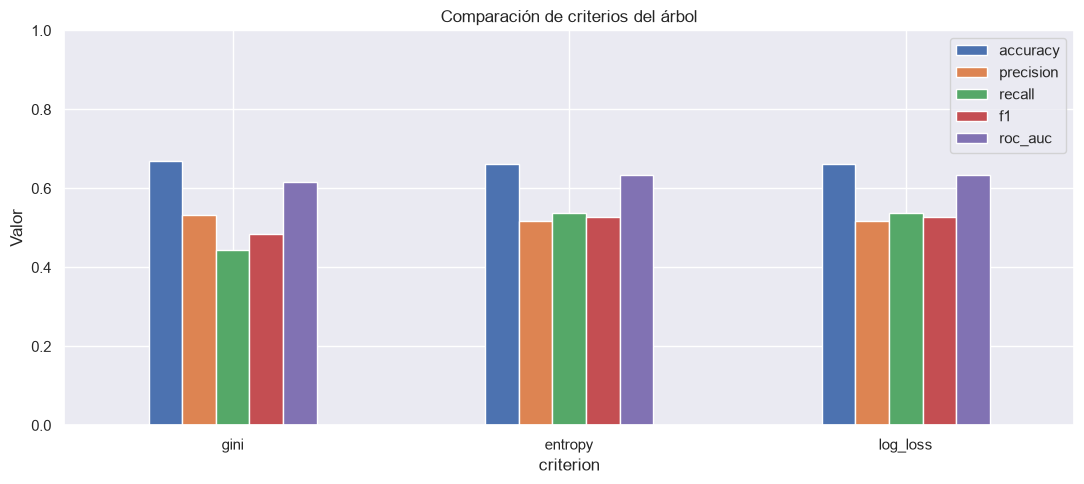

In [23]:
comparison_criteria.set_index("criterion")[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(
    kind="bar", figsize=(11,5)
)
plt.title("Comparación de criterios del árbol")
plt.ylabel("Valor")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.3 Mejor criterio

In [24]:
best_criterion = comparison_criteria.sort_values("f1", ascending=False).iloc[0]["criterion"]
print("Mejor criterio según F1:", best_criterion)

Mejor criterio según F1: entropy


## 3.4 Evaluación del mejor criterio

In [25]:
best_tree_initial = modelos_criterio[best_criterion]
best_pred_initial = best_tree_initial.predict(X_test)
best_prob_initial = best_tree_initial.predict_proba(X_test)[:, 1]

print(classification_report(y_test, best_pred_initial))

              precision    recall  f1-score   support

           0       0.74      0.73      0.74       100
           1       0.52      0.54      0.53        54

    accuracy                           0.66       154
   macro avg       0.63      0.63      0.63       154
weighted avg       0.67      0.66      0.66       154



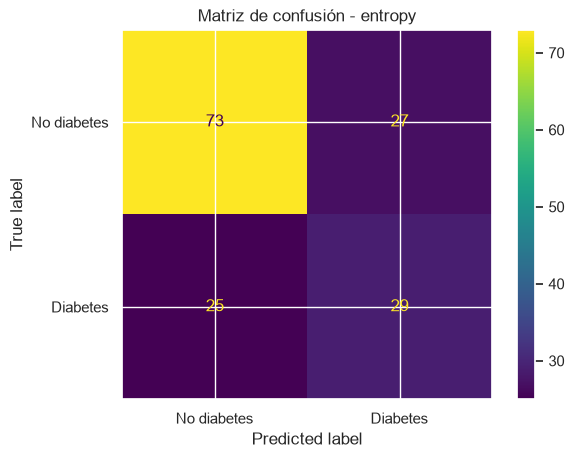

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred_initial, display_labels=["No diabetes", "Diabetes"]
)
plt.title(f"Matriz de confusión - {best_criterion}")
plt.show()

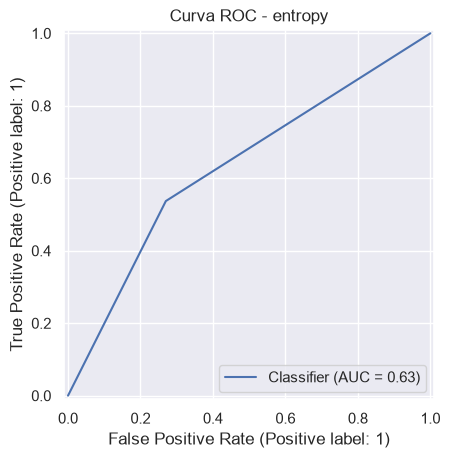

In [27]:
RocCurveDisplay.from_predictions(y_test, best_prob_initial)
plt.title(f"Curva ROC - {best_criterion}")
plt.show()

## 3.5 Importancia de variables

In [28]:
feature_importance = pd.DataFrame({
    "variable": X.columns,
    "importancia": best_tree_initial.feature_importances_
}).sort_values("importancia", ascending=False)
feature_importance

,variable,importancia
1,Glucose,0.276965
5,BMI,0.219406
6,DiabetesPedigreeFunction,0.142593
2,BloodPressure,0.114280
0,Pregnancies,0.071897
7,Age,0.068459
4,Insulin,0.064182
3,SkinThickness,0.042218


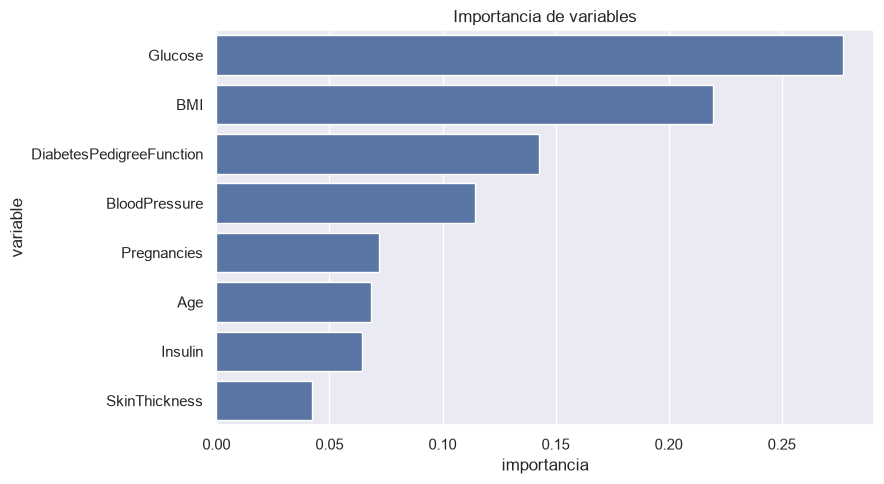

In [29]:
plt.figure(figsize=(9,5))
sns.barplot(data=feature_importance, x="importancia", y="variable")
plt.title("Importancia de variables")
plt.tight_layout()
plt.show()

## 3.6 Visualización del árbol inicial

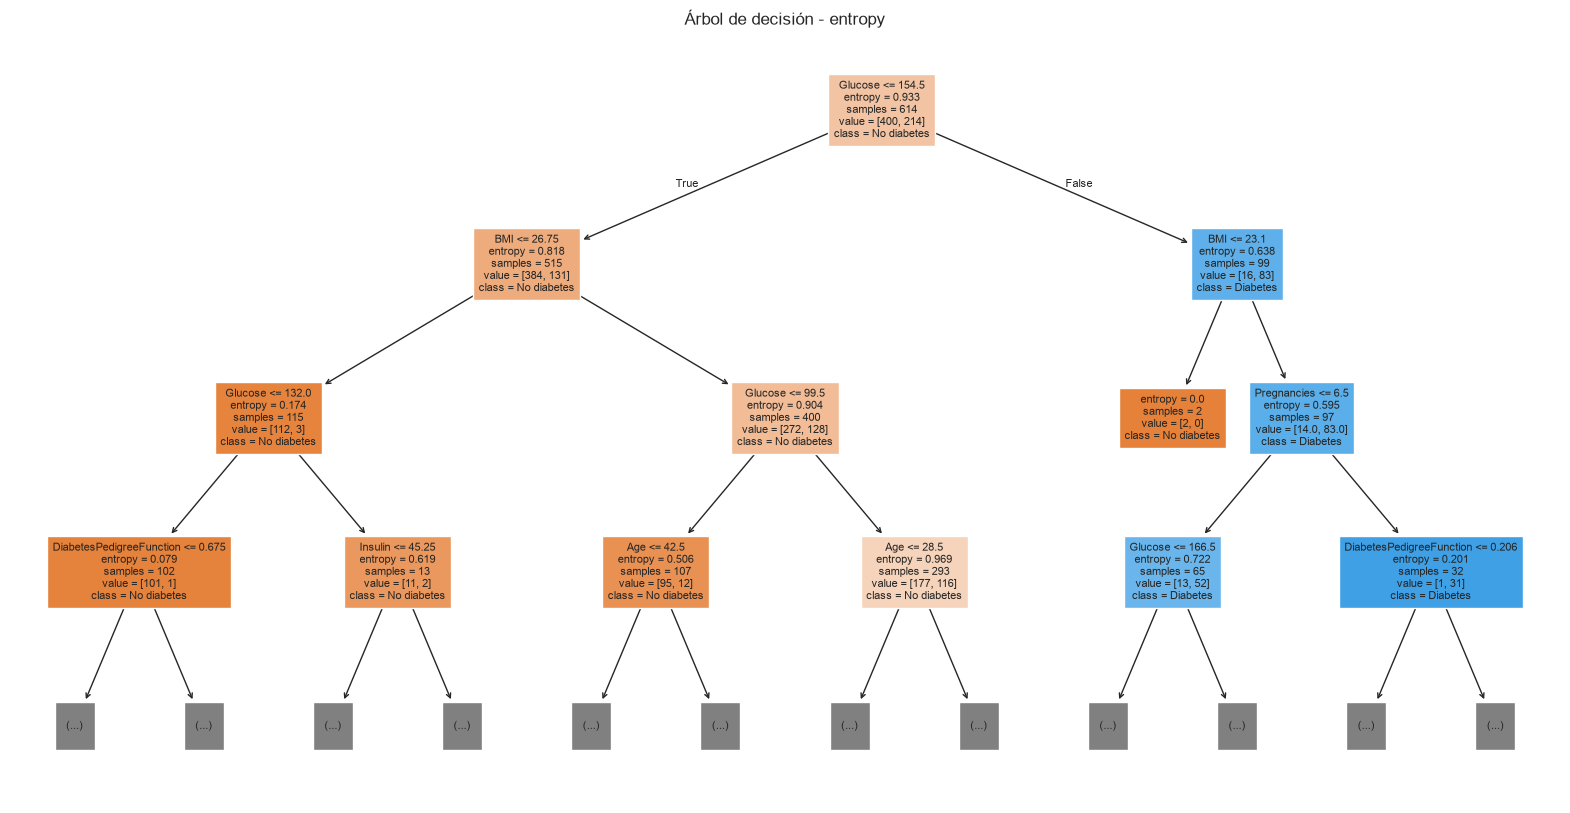

In [30]:
plt.figure(figsize=(20,10))
plot_tree(
    best_tree_initial,
    feature_names=X.columns,
    class_names=["No diabetes", "Diabetes"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title(f"Árbol de decisión - {best_criterion}")
plt.show()

# Paso 4: Optimización del modelo

## 4.1 Grid Search

In [31]:
param_grid = {
    "criterion": [best_criterion],
    "max_depth": [3, 4, 5, 6, 8, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [None, "sqrt", "log2"]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Mejores parámetros:")
print(grid_search.best_params_)
print("\nMejor F1 de validación:")
print(grid_search.best_score_)

Mejores parámetros:
{'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}

Mejor F1 de validación:
0.6291697016517677


## 4.2 Evaluación del árbol optimizado

In [32]:
optimized_tree = grid_search.best_estimator_
y_pred_optimized = optimized_tree.predict(X_test)
y_prob_optimized = optimized_tree.predict_proba(X_test)[:, 1]

metrics_optimized = pd.Series({
    "accuracy": accuracy_score(y_test, y_pred_optimized),
    "precision": precision_score(y_test, y_pred_optimized, zero_division=0),
    "recall": recall_score(y_test, y_pred_optimized, zero_division=0),
    "f1": f1_score(y_test, y_pred_optimized, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_optimized)
})
metrics_optimized

accuracy     0.701299
precision    0.590909
recall       0.481481
f1           0.530612
roc_auc      0.760556
dtype: float64

## 4.3 Comparación del modelo inicial y optimizado

In [33]:
metrics_initial = pd.Series({
    "accuracy": accuracy_score(y_test, best_pred_initial),
    "precision": precision_score(y_test, best_pred_initial, zero_division=0),
    "recall": recall_score(y_test, best_pred_initial, zero_division=0),
    "f1": f1_score(y_test, best_pred_initial, zero_division=0),
    "roc_auc": roc_auc_score(y_test, best_prob_initial)
})

comparison_models = pd.DataFrame({
    "Árbol inicial": metrics_initial,
    "Árbol optimizado": metrics_optimized
}).T
comparison_models

,accuracy,precision,recall,f1,roc_auc
Árbol inicial,0.662338,0.517857,0.537037,0.527273,0.633519
Árbol optimizado,0.701299,0.590909,0.481481,0.530612,0.760556


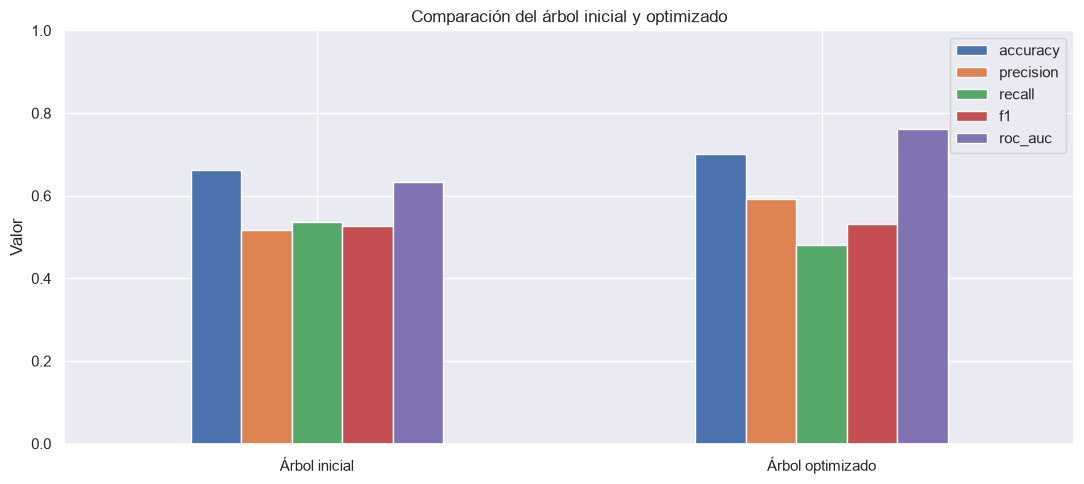

In [34]:
comparison_models.plot(kind="bar", figsize=(11,5))
plt.title("Comparación del árbol inicial y optimizado")
plt.ylabel("Valor")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4.4 Matriz de confusión del modelo optimizado

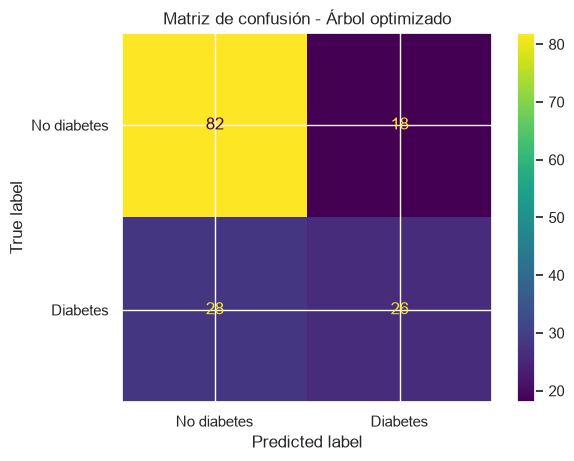

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_optimized, display_labels=["No diabetes", "Diabetes"]
)
plt.title("Matriz de confusión - Árbol optimizado")
plt.show()

## 4.5 Árbol optimizado

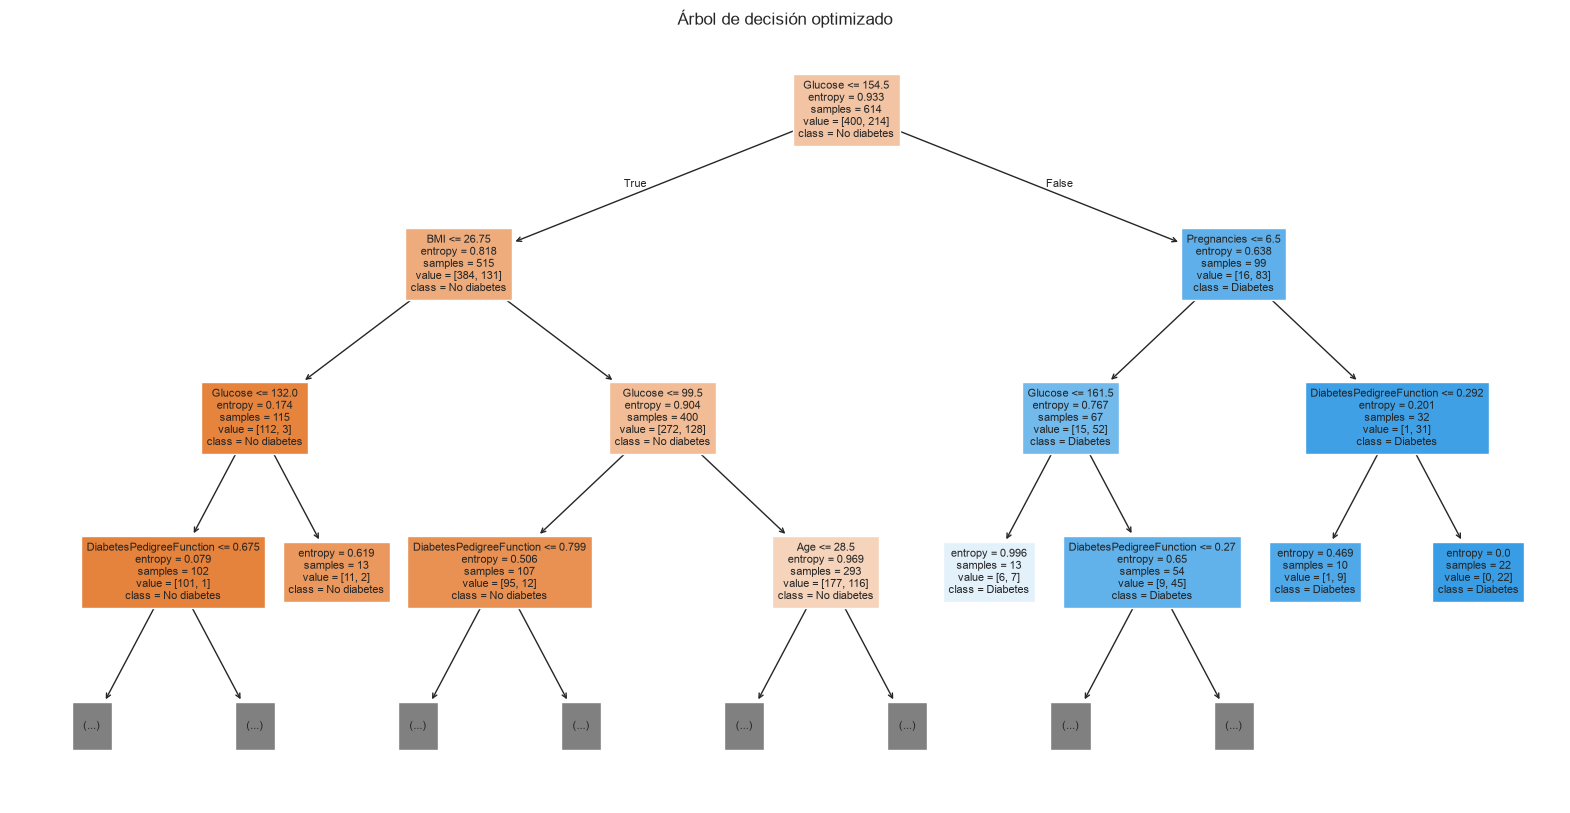

In [36]:
plt.figure(figsize=(20,10))
plot_tree(
    optimized_tree,
    feature_names=X.columns,
    class_names=["No diabetes", "Diabetes"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Árbol de decisión optimizado")
plt.show()

# Paso 5: Guardar el modelo

In [37]:
os.makedirs("../models", exist_ok=True)
model_path = "../models/decision_tree_diabetes.pkl"
joblib.dump(optimized_tree, model_path)
print("Modelo guardado en:", model_path)

Modelo guardado en: ../models/decision_tree_diabetes.pkl


# Conclusiones generales

El análisis exploratorio mostró que la glucosa, el índice de masa corporal, la edad y el número de embarazos presentan las diferencias más evidentes entre pacientes con y sin diabetes. La glucosa fue además la variable con mayor correlación con la variable objetivo y la característica de mayor importancia dentro del árbol de decisión.

Durante la preparación de los datos se identificaron valores iguales a cero en variables clínicas donde dicho valor no resulta razonable. Estos fueron tratados mediante imputación con la mediana. También se observó un desbalance moderado en la variable objetivo, con aproximadamente 65 % de pacientes sin diabetes y 35 % con diabetes.

Entre los criterios evaluados para el árbol de decisión, entropy presentó un buen equilibrio entre las métricas iniciales. Posteriormente, la optimización del modelo incrementó el accuracy de aproximadamente 66 % a 70 % y el ROC-AUC de 0.63 a 0.76, mostrando una mejora importante en la capacidad general de discriminación del modelo.

Sin embargo, el recall de la clase positiva disminuyó aproximadamente de 54 % a 48 %. Esto significa que, aunque el modelo optimizado mejora su desempeño global y reduce los falsos positivos, también deja sin detectar una mayor proporción de pacientes con diabetes.

Por esta razón, para una aplicación orientada a la detección de diabetes no sería recomendable seleccionar el modelo únicamente por accuracy o ROC-AUC. Sería conveniente continuar la optimización priorizando el recall de la clase positiva, buscando reducir los falsos negativos, aunque esto implique aceptar un número ligeramente mayor de falsos positivos.

el modelo optimizado no es automáticamente el mejor modelo para el problema de negocio simplemente porque tenga mayor accuracy. La métrica de optimización debe elegirse de acuerdo con el costo de cada tipo de error.  